# 02 · Modelo — Árbol de Decisión
### Entrenamiento · Optimización · Evaluación · Persistencia
---


In [1]:
import sys, os
_here = os.getcwd()
ROOT = _here
for _ in range(5): 
    if os.path.isdir(os.path.join(ROOT, 'src')):
        break
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)
print(f'ROOT detectado: {ROOT}')

ROOT detectado: c:\Users\PC\Downloads\Proyecto_ML


In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, learning_curve)
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, recall_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)

from src.data_loader import DataLoader
from src.preprocessing import ProcesadorDatos

# Rutas
TRAINED_DIR = os.path.join(ROOT, 'models', 'trained')
FIGURES_DIR = os.path.join(ROOT, 'reports', 'figures')
os.makedirs(TRAINED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Cargar y preparar datos (reutiliza src/preprocessing.py)
loader     = DataLoader(os.path.join(ROOT, 'data', 'indian_roads_dataset.csv'))
df         = loader.cargar_datos()
procesador = ProcesadorDatos()
X, y       = procesador.preparar_datos(df)

SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Features: {X_train.shape[1]}')

Train: 16,000  |  Test: 4,000
Features: 43


Carga los datos ya previamente procesados. 

## 2.1 Hiperparámetros 
buscados con GridSearchCV

In [3]:
params = {
    'max_depth'        : [8, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : [None, 'balanced'],
}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    params, cv=CV, scoring='f1_weighted', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)

display(pd.DataFrame(list(gs.best_params_.items()),columns=['Hiperparámetro','Valor óptimo']).style.set_caption(f'Mejores hiperparámetros — CV F1 train: {gs.best_score_:.4f}').hide(axis='index'))


Fitting 5 folds for each of 144 candidates, totalling 720 fits


Hiperparámetro,Valor óptimo
class_weight,None
criterion,entropy
max_depth,12
min_samples_leaf,2
min_samples_split,10


El GridSearch encontró una configuración óptima donde el árbol tiene una profundidad controlada, requiere un mínimo de muestras para dividir y evita hojas demasiado pequeñas.

Esto indica que el modelo busca generalizar bien sin sobreajustarse. 

F1-score obtenido (0.6184) muestra un desempeño aceptable, aunque con posibilidad de mejora usando modelos más avanzados.

## 2.3 Evaluación en test

In [4]:
arbol   = gs.best_estimator_
y_pred  = arbol.predict(X_test)

display(pd.DataFrame([{'Accuracy':round(accuracy_score(y_test,y_pred),4),'F1 ponderado':round(f1_score(y_test,y_pred,average='weighted'),4),'Recall ponderado':round(recall_score(y_test,y_pred,average='weighted'),4),'Precision ponderada':round(precision_score(y_test,y_pred,average='weighted'),4)}]).style.set_caption('Métricas — Árbol de Decisión').hide(axis='index'))
display(pd.DataFrame(classification_report(y_test,y_pred,output_dict=True)).T.round(4).style.set_caption('Reporte de clasificación completo'))


Accuracy,F1 ponderado,Recall ponderado,Precision ponderada
0.650800,0.618100,0.650800,0.609500


,precision,recall,f1-score,support
fatal,0.998300,1.000000,0.999200,597.000000
major,0.346700,0.187800,0.243600,1198.000000
minor,0.646900,0.807700,0.718400,2205.000000
accuracy,0.650800,0.650800,0.650800,0.650800
macro avg,0.664000,0.665200,0.653700,4000.000000
weighted avg,0.609500,0.650800,0.618100,4000.000000


El dato más relevante es que el modelo logra un recall de 1.0 en la clase fatal, lo que significa que identifica correctamente todos los casos críticos. 

Aunque, el modelo muestra un buen desempeño en la detección de casos críticos y casos comunes, presenta dificultades en la clasificación de eventos intermedios. 

Esto indica que el modelo está aprendiendo patrones extremos, pero no logra diferenciar correctamente los casos de severidad media.

lo que evidencia que el modelo aún no captura completamente la complejidad del problema.

## 2.4 Matriz de confusión

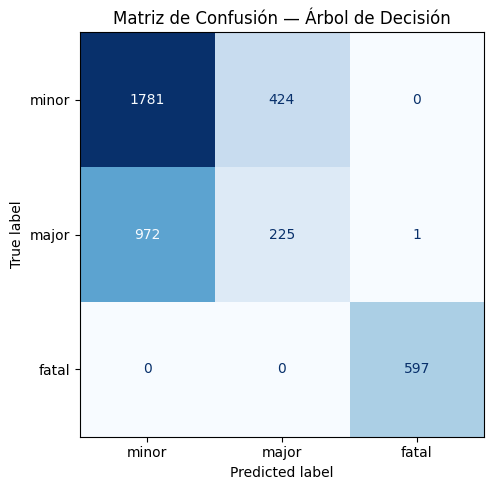

In [5]:
cm = confusion_matrix(y_test, y_pred, labels=['minor','major','fatal'])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['minor','major','fatal']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Árbol de Decisión')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cm_arbol.png'), dpi=110, bbox_inches='tight')
plt.show()


El modelo presenta un problema significativo en la clase major, ya que la mayoría de estos casos son clasificados incorrectamente como minor. 

Esto evidencia que el modelo no logra distinguir adecuadamente entre niveles intermedios de severidad.

## 2.5 Importancia de features

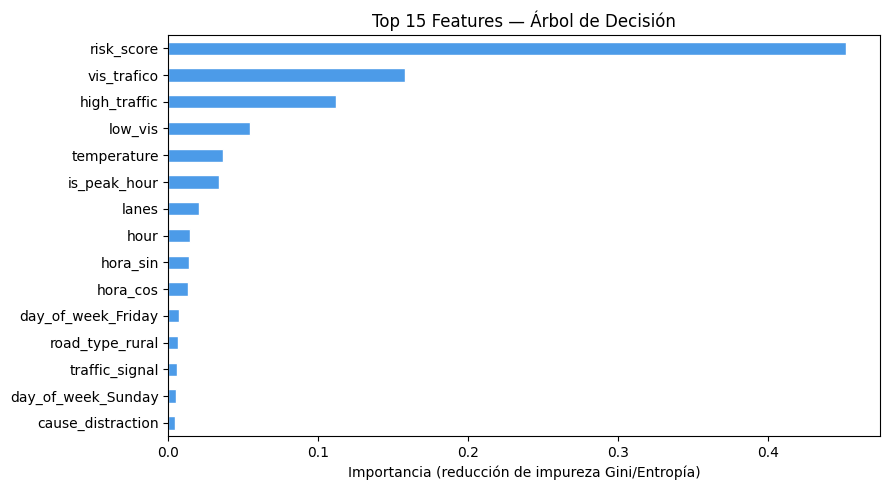

Feature,Importancia
risk_score,0.452100
vis_trafico,0.157700
high_traffic,0.111600
low_vis,0.054400
temperature,0.036600
is_peak_hour,0.033600
lanes,0.020700
hour,0.014100
hora_sin,0.013900
hora_cos,0.012700


In [6]:
imp = (pd.Series(arbol.feature_importances_, index=X_train.columns)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 5))
imp[::-1].plot(kind='barh', ax=ax, color='#4C9BE8', edgecolor='white')
ax.set_title('Top 15 Features — Árbol de Decisión')
ax.set_xlabel('Importancia (reducción de impureza Gini/Entropía)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feat_imp_arbol.png'), dpi=110, bbox_inches='tight')
plt.show()
display(imp.round(4).reset_index().rename(columns={'index':'Feature',0:'Importancia'}).style.set_caption('Top 15 features — Árbol de Decisión').hide(axis='index'))


## 2.6 Visualización del árbol (3 niveles)

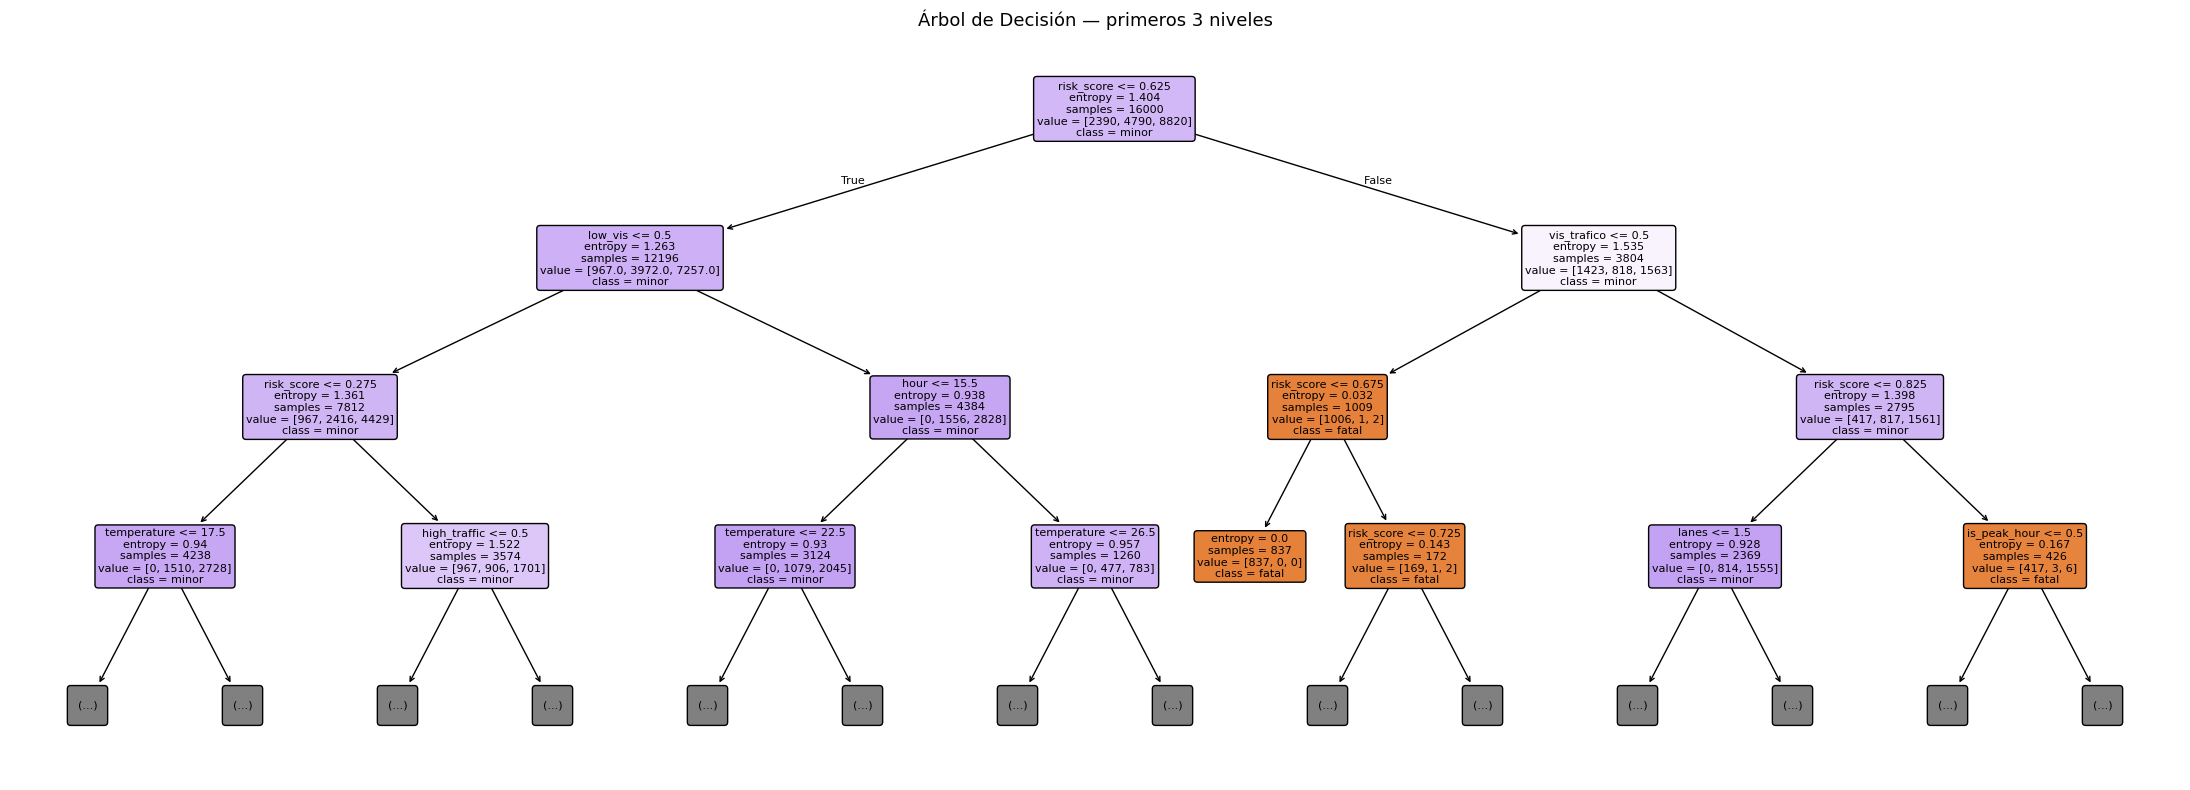

Profundidad total : 12
Número de hojas   : 718


In [7]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(arbol,
          feature_names=X_train.columns.tolist(),
          class_names=['fatal','major','minor'],
          max_depth=3, filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión — primeros 3 niveles', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'arbol_decision.png'), dpi=90, bbox_inches='tight')
plt.show()
print(f'Profundidad total : {arbol.get_depth()}')
print(f'Número de hojas   : {arbol.get_n_leaves()}')


## 2.7 Curva de aprendizaje

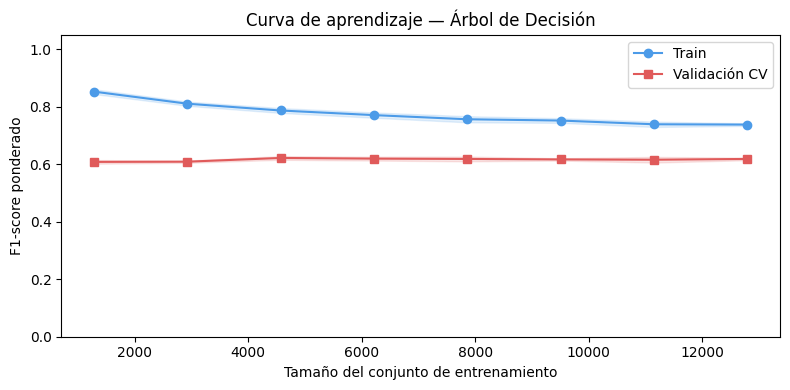

In [8]:
tr_sz, tr_sc, val_sc = learning_curve(
    arbol, X_train, y_train,
    cv=CV, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tr_sz, tr_sc.mean(axis=1),  'o-', color='#4C9BE8', label='Train')
ax.plot(tr_sz, val_sc.mean(axis=1), 's-', color='#E05A5A', label='Validación CV')
ax.fill_between(tr_sz,
    tr_sc.mean(axis=1) - tr_sc.std(axis=1),
    tr_sc.mean(axis=1) + tr_sc.std(axis=1), alpha=0.15, color='#4C9BE8')
ax.fill_between(tr_sz,
    val_sc.mean(axis=1) - val_sc.std(axis=1),
    val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.15, color='#E05A5A')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('F1-score ponderado')
ax.set_title('Curva de aprendizaje — Árbol de Decisión')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'lc_arbol.png'), dpi=110, bbox_inches='tight')
plt.show()


La curva de aprendizaje muestra que el modelo tiene un desempeño mayor en el conjunto de entrenamiento que en validación, lo que indica la presencia de sobreajuste moderado.

Estos resultados indican que el modelo de Árbol de Decisión tiene limitaciones para capturar relaciones más complejas en los datos, lo que explica su bajo desempeño en ciertas clases como "major".

## 2.8 Guardar modelo en `models/trained/`

In [9]:
ruta_pkl = os.path.join(TRAINED_DIR, 'arbol.pkl')
joblib.dump(arbol, ruta_pkl)
display(pd.DataFrame([{'Archivo':ruta_pkl,'Tamaño KB':round(os.path.getsize(ruta_pkl)/1024,1),'Estado':'Guardado'}]).style.set_caption('Modelo persistido en models/trained/').hide(axis='index'))


Archivo,Tamaño KB,Estado
c:\Users\PC\Downloads\Proyecto_ML\models\trained\arbol.pkl,125.700000,Guardado
